## Stage 4 — Modeling: Prophet vs LightGBM

Train/val/test split by time: train d_1–1913, validation d_1914–1941, test
d_1942–1969 (held-out, from `sales_test_evaluation.csv`). Both models evaluated
on the same 300-series stratified subset using RMSSE.

### 4.1 Data splits & representative subset

### Load Feature Matrix and Define Time Splits

In [1]:
# Load feature matrix and define time splits
import pandas as pd
import numpy as np
from pathlib import Path

OUT = Path("outputs")
df = pd.read_parquet(OUT / "foods_features.parquet")
print("Shape:", df.shape)
print("d_num range:", df["d_num"].min(), "->", df["d_num"].max())

# M5 standard splits (test set is the separate file: d_1942-1969)
TRAIN_END = 1913   # train: d_1 .. d_1913
VAL_END   = 1941   # validation: d_1914 .. d_1941 (last 28 days of train file)
# test: d_1942 .. d_1969 lives in sales_test_evaluation.csv (loaded later)

train = df[df["d_num"] <= TRAIN_END]
val   = df[(df["d_num"] > TRAIN_END) & (df["d_num"] <= VAL_END)]

print(f"\nTrain: d_1..d_{TRAIN_END}  ->  {len(train):,} rows")
print(f"Val:   d_{TRAIN_END+1}..d_{VAL_END}  ->  {len(val):,} rows")
print(f"Test:  d_{VAL_END+1}..d_1969  ->  (in sales_test_evaluation.csv)")

Shape: (21798313, 24)
d_num range: 1 -> 1941

Train: d_1..d_1913  ->  21,395,953 rows
Val:   d_1914..d_1941  ->  402,360 rows
Test:  d_1942..d_1969  ->  (in sales_test_evaluation.csv)


### Representative Series Subset

A representative subset of product-store series is created for model comparison. The subset is stratified by department and activity level, so it includes low-, mid-, and high-activity series from FOODS_1, FOODS_2, and FOODS_3. This makes the evaluation more balanced and avoids judging models only on high-selling products.

In [2]:
# Build a representative series subset (stratified)
# Per-series summary: department + intermittency (active-day ratio)
series_info = df.groupby("id", observed=True).agg(
    dept=("dept_id", "first"),
    active_ratio=("sales", lambda s: (s > 0).mean()),
    mean_sales=("sales", "mean"),
).reset_index()

# Stratify by department and intermittency tier (low/mid/high activity)
series_info["activity_tier"] = pd.cut(
    series_info["active_ratio"], bins=[0, 0.2, 0.5, 1.0],
    labels=["low", "mid", "high"], include_lowest=True
)

print("Series distribution by dept x activity tier:")
print(series_info.groupby(["dept", "activity_tier"], observed=True).size().unstack())

Series distribution by dept x activity tier:
activity_tier  low   mid  high
dept                          
FOODS_1        310  1084   766
FOODS_2        539  2026  1415
FOODS_3        699  3372  4159


### Sampled Series for Model Comparison

A total of 300 series are selected for Prophet and LightGBM comparison. The subset includes 172 FOODS_3 series, 83 FOODS_2 series, and 45 FOODS_1 series. It also includes 32 low-activity, 135 mid-activity, and 133 high-activity series, which helps test model performance across different demand patterns.

In [3]:
# Sample ~300 series proportionally across strata
N_SAMPLE = 300
rng = np.random.RandomState(42)

# proportional allocation across dept x tier strata
sampled_ids = (
    series_info.groupby(["dept", "activity_tier"], observed=True, group_keys=False)
    .apply(lambda g: g.sample(
        n=max(1, round(N_SAMPLE * len(g) / len(series_info))),
        random_state=42), include_groups=False)
)
subset_ids = series_info.loc[sampled_ids.index, "id"].tolist()

print(f"Selected {len(subset_ids)} series for Prophet/LightGBM comparison")
# verify coverage
sub_info = series_info[series_info["id"].isin(subset_ids)]
print("\nSubset coverage by dept:")
print(sub_info["dept"].value_counts())
print("\nSubset coverage by activity tier:")
print(sub_info["activity_tier"].value_counts())

Selected 300 series for Prophet/LightGBM comparison

Subset coverage by dept:
dept
FOODS_3    172
FOODS_2     83
FOODS_1     45
Name: count, dtype: int64

Subset coverage by activity tier:
activity_tier
mid     135
high    133
low      32
Name: count, dtype: int64


### Save Split Configuration

The training end date, validation end date, and selected subset IDs are saved for reuse. This helps keep the modeling process consistent and ensures that Prophet and LightGBM are evaluated on the same product-store series.

In [4]:
# Save splits and subset for reuse
import json
split_config = {
    "train_end": TRAIN_END,
    "val_end": VAL_END,
    "subset_ids": subset_ids,
}
with open(OUT / "split_config.json", "w") as f:
    json.dump(split_config, f)
print(f"Saved split config: {len(subset_ids)} subset series, "
      f"train<=d{TRAIN_END}, val<=d{VAL_END}")

Saved split config: 300 subset series, train<=d1913, val<=d1941


### Evaluation Metrics

RMSSE and MAE are used to evaluate forecast accuracy. RMSSE scales forecast errors by each series’ historical variation, making results more comparable across products with different sales volumes. MAE is also included because it is easy to interpret as the average absolute sales error.

RMSSE < 1 beats the naive (yesterday=today) forecast.

In [5]:
# Test the metrics
from evaluation_index import rmsse, mae

# toy example: a series that sold [1,2,1,3,2...] in training
y_train = np.array([1, 2, 1, 3, 2, 1, 2, 3, 1, 2], dtype=float)
y_true  = np.array([2, 1, 3, 2], dtype=float)     # test actuals
y_perfect = y_true.copy()                          # perfect forecast
y_naive   = np.full(4, y_train[-1])                # predict last value

print("Perfect forecast -> RMSSE:", round(rmsse(y_true, y_perfect, y_train), 3),
      "| MAE:", round(mae(y_true, y_perfect), 3))
print("Flat/naive forecast -> RMSSE:", round(rmsse(y_true, y_naive, y_train), 3),
      "| MAE:", round(mae(y_true, y_naive), 3))
print("\nExpect: perfect RMSSE=0, naive RMSSE around 1")

Perfect forecast -> RMSSE: 0.0 | MAE: 0.0
Flat/naive forecast -> RMSSE: 0.548 | MAE: 0.5

Expect: perfect RMSSE=0, naive RMSSE around 1


### 4.2 Prophet Model

Prophet is first tested on a high-activity product-store series. Prophet is useful because it can automatically model trend, weekly seasonality, and yearly seasonality. This makes it a good interpretable benchmark for time series forecasting, especially for series with relatively regular sales patterns.

In [6]:
import sys
from prophet import Prophet

# === Cell 63: Prophet on one high-activity series (show what it does well) ===
import json
with open(OUT / "split_config.json") as f:
    cfg = json.load(f)
subset_ids = cfg["subset_ids"]
TRAIN_END, VAL_END = cfg["train_end"], cfg["val_end"]

# pick a high-activity FOODS_3 series from the subset
df_sub = df[df["id"].isin(subset_ids)]
activity = df_sub.groupby("id", observed=True)["sales"].apply(lambda s: (s > 0).mean())
demo_id = activity.idxmax()   # most active series

one = df[df["id"] == demo_id].sort_values("date")
train_one = one[one["d_num"] <= TRAIN_END]

# Prophet format: ds (date), y (value)
pdf = train_one[["date", "sales"]].rename(columns={"date": "ds", "sales": "y"})

m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m.fit(pdf)
print(f"Fitted Prophet on {demo_id} ({len(pdf)} training days)")


C:\Users\kyoaj\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
16:57:37 - cmdstanpy - INFO - Chain [1] start processing
16:57:37 - cmdstanpy - INFO - Chain [1] done processing


Fitted Prophet on FOODS_3_252_TX_1_evaluation (1913 training days)


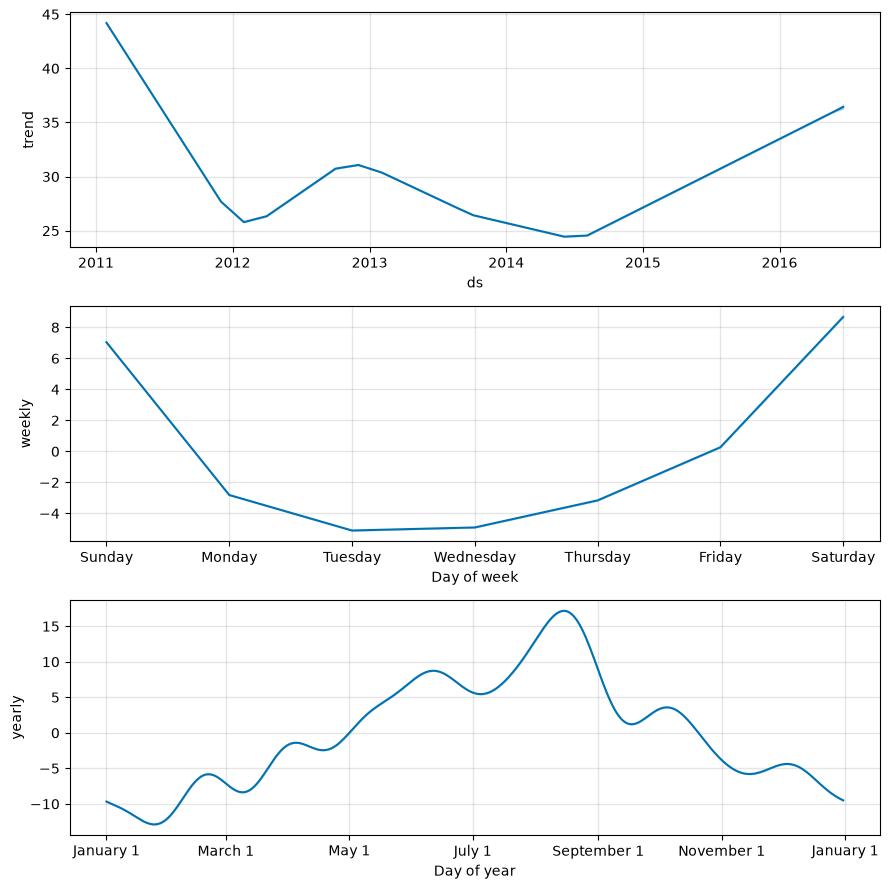

In [7]:
# Forecast + decomposition plot
import matplotlib.pyplot as plt

# forecast through the test period (need 28 days past training)
future = m.make_future_dataframe(periods=VAL_END - TRAIN_END + 28)  # val + test horizon
forecast = m.predict(future)

# Prophet's built-in component plot — the "interpretability" selling point
# use light style so the (black) axis labels/titles are visible
with plt.style.context("default"):
    fig = m.plot_components(forecast)
    plt.tight_layout()
    plt.show()

### Prophet Forecast on High-Activity Series

Prophet is first tested on a smooth, high-activity product-store series. The model fits this type of series relatively well because the demand pattern is more regular and has fewer zero-sales days. Its main advantage is interpretability: the component plot separates the forecast into trend, weekly seasonality, and yearly seasonality, making it easier to understand patterns such as demand recovery, weekend lift, and seasonal peaks.


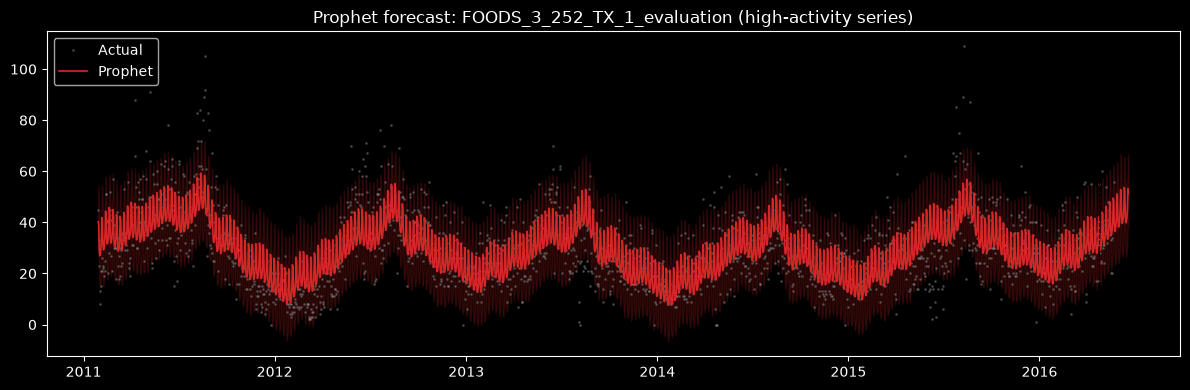

In [8]:
# Visualize fit + forecast vs actual
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one["date"], one["sales"], ".", ms=2, alpha=0.4, color="gray", label="Actual")
ax.plot(forecast["ds"], forecast["yhat"], color="#d62728", lw=1.2, label="Prophet")
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                color="#d62728", alpha=0.15)
ax.axvline(one[one["d_num"] == TRAIN_END]["date"].iloc[0], ls="--", color="black", lw=0.8)
ax.set_title(f"Prophet forecast: {demo_id} (high-activity series)")
ax.legend(); plt.tight_layout(); plt.show()

In [9]:
# Prophet on a LOW-activity (intermittent) series
# pick the most intermittent series from the subset
demo_id_low = activity.idxmin()
one_low = df[df["id"] == demo_id_low].sort_values("date")
train_low = one_low[one_low["d_num"] <= TRAIN_END]
print(f"Series: {demo_id_low} | active days: {(train_low['sales']>0).mean()*100:.1f}%")

pdf_low = train_low[["date", "sales"]].rename(columns={"date": "ds", "sales": "y"})
m_low = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m_low.fit(pdf_low)

future_low = m_low.make_future_dataframe(periods=VAL_END - TRAIN_END + 28)
fc_low = m_low.predict(future_low)

Series: FOODS_2_071_TX_3_evaluation | active days: 1.9%


16:57:38 - cmdstanpy - INFO - Chain [1] start processing
16:57:38 - cmdstanpy - INFO - Chain [1] done processing


### Prophet on Low-Activity Series

Prophet is also tested on a low-activity intermittent series that has positive sales on only about 2% of training days. The forecast becomes almost flat and stays close to zero, while the prediction intervals even include negative values. This shows that Prophet struggles to represent sporadic demand spikes and is not well suited for highly intermittent retail sales series.


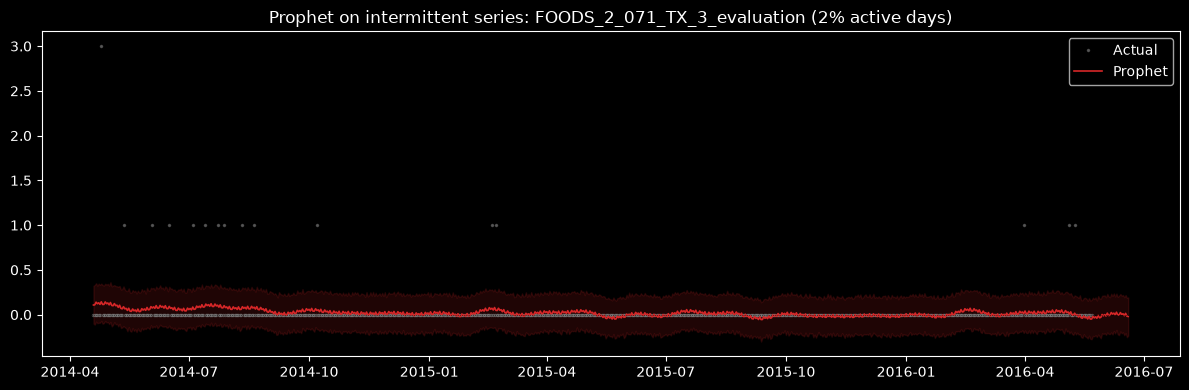

Negative predictions: 32.7% of forecast days
Actual is integer counts, Prophet predicts: mean=0.02 (non-integer, often near-zero)


In [10]:
# Visualize Prophet failing on intermittent demand
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_low["date"], one_low["sales"], ".", ms=3, alpha=0.5, color="gray", label="Actual")
ax.plot(fc_low["ds"], fc_low["yhat"], color="#d62728", lw=1.2, label="Prophet")
ax.fill_between(fc_low["ds"], fc_low["yhat_lower"], fc_low["yhat_upper"],
                color="#d62728", alpha=0.15)
ax.axhline(0, color="black", lw=0.5, ls=":")
ax.set_title(f"Prophet on intermittent series: {demo_id_low} "
             f"({(train_low['sales']>0).mean()*100:.0f}% active days)")
ax.legend(); plt.tight_layout(); plt.show()

print("Negative predictions:", f"{(fc_low['yhat'] < 0).mean()*100:.1f}% of forecast days")
print("Actual is integer counts, Prophet predicts:",
      f"mean={fc_low['yhat'].mean():.2f} (non-integer, often near-zero)")

### Load Final Test Actuals

The final test-period actual sales are loaded from `sales_test_evaluation.csv`. The test set covers days `d_1942` to `d_1969`, which represents a 28-day forecasting horizon. It contains 402,360 rows, based on 14,370 product-store series across 28 days.

In [11]:
# Load test-period actuals (d_1942-1969)
test_raw = pd.read_csv(r"C:\Users\kyoaj\ALY 6140\ALY 6140\final project\m5\sales_test_evaluation.csv")
test_foods = test_raw[test_raw["cat_id"] == "FOODS"].copy()
test_foods["id"] = test_foods["item_id"] + "_" + test_foods["store_id"] + "_evaluation"

d_test_cols = [c for c in test_foods.columns if c.startswith("d_")]
test_long = test_foods.melt(
    id_vars=["id"], value_vars=d_test_cols,
    var_name="d", value_name="sales"
)
test_long["d_num"] = test_long["d"].str.replace("d_", "").astype(int)
test_long["sales"] = test_long["sales"].astype("int16")

print(f"Test period: d_{test_long['d_num'].min()}-d_{test_long['d_num'].max()}")
print(f"Test rows: {len(test_long):,} ({test_long['id'].nunique()} series x 28 days)")

Test period: d_1942-d_1969
Test rows: 402,360 (14370 series x 28 days)


In [12]:
# Run Prophet batch evaluation (takes a few minutes)
from evaluate_prophet import evaluate_prophet_batch

import time; t = time.time()
prophet_results = evaluate_prophet_batch(
    df, test_long, subset_ids, TRAIN_END, horizon=28
)
print(f"\nDone in {time.time()-t:.0f}s. Evaluated {len(prophet_results)} series.")
prophet_results.to_parquet(OUT / "prophet_results.parquet", index=False)

  50/300 done
  100/300 done
  150/300 done
  200/300 done
  250/300 done
  300/300 done

Done in 99s. Evaluated 300 series.


### Prophet  Evaluation

Prophet is evaluated on the same 300-series subset. The overall mean RMSSE is 0.831, the median RMSSE is 0.748, and the mean MAE is 1.487. Performance is worse for low-activity series, with a mean RMSSE of 0.964, confirming that intermittent demand is more difficult for Prophet.

In [13]:
# Summarize Prophet performance
res = prophet_results.merge(series_info[["id", "dept", "activity_tier"]], on="id")

print("=== Prophet overall ===")
print(f"Mean RMSE: {res['rmse'].mean():.3f}")
print(f"Mean RMSSE: {res['rmsse'].mean():.3f}")
print(f"Median RMSSE: {res['rmsse'].median():.3f}")
print(f"Mean MAE: {res['mae'].mean():.3f}")

print("\n=== RMSSE by activity tier (expect worse on low-activity) ===")
print(res.groupby("activity_tier", observed=True)["rmsse"].agg(["mean", "median", "count"]))

=== Prophet overall ===
Mean RMSE: 1.895
Mean RMSSE: 0.831
Median RMSSE: 0.748
Mean MAE: 1.487

=== RMSSE by activity tier (expect worse on low-activity) ===
                   mean    median  count
activity_tier                           
low            0.964105  0.806345     32
mid            0.834426  0.748397    135
high           0.796105  0.730563    133


### 4.3 LightGBM model


### Prepare Training Data for LightGBM

LightGBM is trained using the 20 engineered features from the feature engineering stage. These features include calendar variables, lag features, rolling statistics, price features, event features, SNAP indicators, and static identifiers such as item, department, store, and state. The training set contains 21,395,953 rows.

In [14]:
# Prepare training data for LightGBM
import lightgbm as lgb

# feature columns (same 20 features from Stage 3)
feature_cols = [
    "dayofweek", "is_weekend", "month", "dayofyear",      # calendar
    "lag_7", "lag_14", "lag_28",                          # lag
    "roll_mean_7", "roll_std_7", "roll_mean_28", "roll_std_28",  # rolling
    "sell_price", "price_vs_median",                      # price
    "event_name_1", "event_type_1",                       # event
    "snap",                                               # snap
    "item_id", "dept_id", "store_id", "state_id",         # static
]
categorical_feats = ["event_name_1", "event_type_1",
                     "item_id", "dept_id", "store_id", "state_id"]
target = "sales"

# train = d_1..d_1913 (everything before validation/test)
train_df = df[df["d_num"] <= TRAIN_END]
print(f"Training rows: {len(train_df):,} ({train_df['id'].nunique()} series)")
print(f"Features: {len(feature_cols)} | Categorical: {len(categorical_feats)}")

Training rows: 21,395,953 (14370 series)
Features: 20 | Categorical: 6


### LightGBM Dataset

The training data is converted into a LightGBM dataset. Categorical features are specified directly, including event, item, department, store, and state variables. This allows LightGBM to efficiently learn differences across products, stores, and event types without manually creating many dummy variables.

In [15]:
# Build LightGBM Dataset
X_train = train_df[feature_cols]
y_train = train_df[target]

train_set = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=categorical_feats,
    free_raw_data=False,    # keep raw data so we can reuse
)
print("LightGBM Dataset built.")
print(f"X shape: {X_train.shape}")

LightGBM Dataset built.
X shape: (21395953, 20)


### Validation Set

The validation set covers the last 28 days of the training file, from `d_1914` to `d_1941`. This validation period is used for early stopping, helping prevent overfitting and making the model more reliable for the final 28-day test forecast.

In [16]:
# Build validation set (d_1914-1941) for early stopping
val_df = df[(df["d_num"] > TRAIN_END) & (df["d_num"] <= VAL_END)]
for c in categorical_feats:
    if val_df[c].dtype.name != "category":
        val_df[c] = val_df[c].astype("category")

X_val = val_df[feature_cols]
y_val = val_df[target]

val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_feats,
                      reference=train_set)   # reference=train_set aligns categories
print(f"Validation rows: {len(val_df):,}")

Validation rows: 402,360


### Train LightGBM Model

LightGBM is trained with a Tweedie objective, which is suitable for retail demand because the data contains many zero-sales observations and positive continuous-like sales patterns. Early stopping stops training when validation performance no longer improves. The best iteration is 615, with a validation RMSE of 2.378.

In [17]:
# Train LightGBM with early stopping
params = {
    "objective": "tweedie",          # good for count data with many zeros (intermittent!)
    "tweedie_variance_power": 1.1,   # tweedie shape; ~1.1 suits retail demand
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 63,                # model complexity
    "min_data_in_leaf": 100,         # regularization: avoid overfitting tiny groups
    "feature_fraction": 0.8,         # use 80% features per tree (regularization)
    "bagging_fraction": 0.8,         # use 80% rows per tree
    "bagging_freq": 1,
    "verbose": -1,
    "num_threads": -1,               # use all cores
}

import time; t = time.time()
model = lgb.train(
    params,
    train_set,
    num_boost_round=1000,
    valid_sets=[train_set, val_set],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),   # stop if val doesn't improve for 50 rounds
        lgb.log_evaluation(period=50),            # print every 50 rounds
    ],
)
print(f"\nTrained in {time.time()-t:.0f}s. Best iteration: {model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 3.05969	val's rmse: 2.46504
[100]	train's rmse: 2.95788	val's rmse: 2.39972
[150]	train's rmse: 2.92063	val's rmse: 2.38926
[200]	train's rmse: 2.89133	val's rmse: 2.38527
[250]	train's rmse: 2.87027	val's rmse: 2.38376
[300]	train's rmse: 2.84926	val's rmse: 2.38255
[350]	train's rmse: 2.83384	val's rmse: 2.38198
[400]	train's rmse: 2.81989	val's rmse: 2.38069
[450]	train's rmse: 2.80833	val's rmse: 2.38017
[500]	train's rmse: 2.79958	val's rmse: 2.37959
[550]	train's rmse: 2.79226	val's rmse: 2.37876
[600]	train's rmse: 2.78458	val's rmse: 2.37807
[650]	train's rmse: 2.77656	val's rmse: 2.3789
Early stopping, best iteration is:
[615]	train's rmse: 2.78171	val's rmse: 2.37804

Trained in 106s. Best iteration: 615


### Prepare Recursive Forecasting

Recursive forecasting is used to predict the final 28-day test period. The model starts with actual sales history up to `d_1941` and then predicts one day at a time from `d_1942` to `d_1969`. Each new prediction is fed back into the lag and rolling features for the next forecast day.

In [18]:
# Prepare data for recursive forecasting
# We need, for each series: actual sales up to d_1941, plus the "known" features
# (calendar/price/event/snap) for the test period d_1942-1969.

# test-period known features come from the test file + calendar + prices
# build the test-period feature skeleton (sales unknown, to be filled by prediction)

HORIZON_START = VAL_END + 1   # 1942
HORIZON_END = 1969

# history needed for lags: from d_1914 (gives 28-day buffer before 1942) through 1941
hist = df[(df["d_num"] >= HORIZON_START - 28) & (df["d_num"] <= VAL_END)].copy()
print(f"History buffer: d_{hist['d_num'].min()}-d_{hist['d_num'].max()}, {len(hist):,} rows")

History buffer: d_1914-d_1941, 402,360 rows


### Build Test-Period Features

Known future features are prepared for the test period, including calendar variables, event information, SNAP indicators, and sell prices. These features are available at prediction time, so they can be safely used for forecasting without data leakage.

In [19]:
# Build test-period known features (d_1942-1969)
# Load calendar and prices (reuse raw files)
cal = pd.read_csv(r"C:\Users\kyoaj\ALY 6140\ALY 6140\final project\m5\calendar.csv").replace("NA", np.nan)
cal["date"] = pd.to_datetime(cal["date"])
cal = cal.reset_index(drop=True)
cal["d_num"] = (cal.index + 1).astype("int32")

# test period calendar rows
cal_test = cal[(cal["d_num"] >= HORIZON_START) & (cal["d_num"] <= HORIZON_END)].copy()
print(f"Test calendar: d_{cal_test['d_num'].min()}-d_{cal_test['d_num'].max()}, {len(cal_test)} days")
print(cal_test[["d_num", "date", "wm_yr_wk"]].head(3))

Test calendar: d_1942-d_1969, 28 days
      d_num       date  wm_yr_wk
1941   1942 2016-05-23     11617
1942   1943 2016-05-24     11617
1943   1944 2016-05-25     11617


In [20]:
#  drop cat_id, it was excluded as a constant
series_static = df[["id", "item_id", "dept_id", "store_id", "state_id"]].drop_duplicates("id")
print(f"Series: {len(series_static)}")

# cross join: every series x every test day
test_skeleton = series_static.merge(cal_test[["d_num", "date", "wm_yr_wk",
    "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]], how="cross")
print(f"Test skeleton: {len(test_skeleton):,} rows ({len(series_static)} series x {len(cal_test)} days)")

Series: 14370
Test skeleton: 402,360 rows (14370 series x 28 days)


In [21]:
#  apply feature engineering, safe to re-run
# 1) SNAP by state — only if per-state columns still present
if {"snap_CA", "snap_TX", "snap_WI"}.issubset(test_skeleton.columns):
    test_skeleton["snap"] = np.select(
        [test_skeleton["state_id"]=="CA", test_skeleton["state_id"]=="TX", test_skeleton["state_id"]=="WI"],
        [test_skeleton["snap_CA"], test_skeleton["snap_TX"], test_skeleton["snap_WI"]],
        default=0).astype("int8")
    test_skeleton = test_skeleton.drop(columns=["snap_CA","snap_TX","snap_WI"])

# 2) prices — only if not already merged
if "sell_price" not in test_skeleton.columns:
    prices = pd.read_csv(r"C:\Users\kyoaj\ALY 6140\ALY 6140\final project\m5\sell_prices.csv")
    prices["wm_yr_wk"] = prices["wm_yr_wk"].astype("int32")
    test_skeleton = test_skeleton.merge(prices, on=["store_id","item_id","wm_yr_wk"], how="left")

# 3) calendar features
test_skeleton["dayofweek"] = test_skeleton["date"].dt.dayofweek.astype("int8")
test_skeleton["is_weekend"] = (test_skeleton["dayofweek"]>=5).astype("int8")
test_skeleton["month"] = test_skeleton["date"].dt.month.astype("int8")
test_skeleton["dayofyear"] = test_skeleton["date"].dt.dayofyear.astype("int16")

# 4) events
for c in ["event_name_1","event_type_1"]:
    test_skeleton[c] = test_skeleton[c].astype("object").fillna("none").astype("category")

test_skeleton["d_num"] = test_skeleton["d_num"].astype("int32")
print("Test skeleton ready. Columns:", test_skeleton.columns.tolist())
print(f"Price NaN: {test_skeleton['sell_price'].isna().mean()*100:.1f}%")

Test skeleton ready. Columns: ['id', 'item_id', 'dept_id', 'store_id', 'state_id', 'd_num', 'date', 'wm_yr_wk', 'event_name_1', 'event_type_1', 'snap', 'sell_price', 'dayofweek', 'is_weekend', 'month', 'dayofyear']
Price NaN: 0.0%


### Sales History for Recursion

A sales history table is created using actual sales from `d_1914` to `d_1941`, with empty columns added for the test period. This 28-day history buffer is needed to calculate lag and rolling features during recursive forecasting.

In [22]:
# Build sales history wide table for recursion
# rows = series, columns = d_num; seed with real sales d_1914-1941, NaN for test days
hist_start = HORIZON_START - 28   # d_1914, gives 28-day lag buffer
hist_df = df[(df["d_num"] >= hist_start) & (df["d_num"] <= VAL_END)][["id", "d_num", "sales"]]

# pivot to wide: index=id, columns=d_num, values=sales
sales_wide = hist_df.pivot(index="id", columns="d_num", values="sales")
# add empty columns for test days (to be filled by prediction)
for d in range(HORIZON_START, HORIZON_END + 1):
    sales_wide[d] = np.nan
sales_wide = sales_wide.sort_index(axis=1)   # ensure columns in day order

print(f"Sales history wide table: {sales_wide.shape} (series x days)")
print(f"Day columns: {sales_wide.columns.min()} to {sales_wide.columns.max()}")
print(f"Seeded (real) days: {hist_start}-{VAL_END}, to-predict: {HORIZON_START}-{HORIZON_END}")

Sales history wide table: (14370, 56) (series x days)
Day columns: 1914 to 1969
Seeded (real) days: 1914-1941, to-predict: 1942-1969


### Price History for Test Forecasting

A price history table is also created to calculate the `price_vs_median` feature during the test period. Since sell prices are known in advance, price-related features can be used safely when forecasting future sales.

In [23]:
# Build price history wide table (for price_vs_median)
# need prices from ~56 days before test through test period
price_hist_start = HORIZON_START - 56
# training-period prices
price_hist = df[(df["d_num"] >= price_hist_start) & (df["d_num"] <= VAL_END)][["id", "d_num", "sell_price"]]
price_wide = price_hist.pivot(index="id", columns="d_num", values="sell_price")
# test-period prices from skeleton
test_price = test_skeleton.pivot(index="id", columns="d_num", values="sell_price")
price_wide = pd.concat([price_wide, test_price], axis=1).sort_index(axis=1)

print(f"Price history wide: {price_wide.shape}")
print(f"Day range: {price_wide.columns.min()}-{price_wide.columns.max()}")

Price history wide: (14370, 84)
Day range: 1886-1969


### LightGBM Recursive Forecast

The trained LightGBM model generates predictions for all 402,360 test rows. The average prediction is 2.179 units, with a maximum prediction of 162.5 units. Unlike Prophet, LightGBM does not produce negative forecasts, making it more appropriate for sales demand prediction.

In [24]:
# Run recursive forecast
from lgb_predict import recursive_forecast

import time; t = time.time()
lgb_preds = recursive_forecast(
    model, sales_wide.copy(), price_wide, test_skeleton,
    feature_cols, categorical_feats,
    HORIZON_START, HORIZON_END
)
print(f"Recursive forecast done in {time.time()-t:.0f}s")
print(f"Predictions: {lgb_preds.shape}")
print(lgb_preds.head())
print(f"\nPrediction stats: mean={lgb_preds['prediction'].mean():.3f}, "
      f"max={lgb_preds['prediction'].max():.1f}, zeros={ (lgb_preds['prediction']==0).mean()*100:.1f}%")

Recursive forecast done in 2s
Predictions: (402360, 3)
                            id  d_num  prediction
0  FOODS_1_001_CA_1_evaluation   1942    0.639008
1  FOODS_1_001_CA_2_evaluation   1942    0.665913
2  FOODS_1_001_CA_3_evaluation   1942    0.964681
3  FOODS_1_001_CA_4_evaluation   1942    0.337076
4  FOODS_1_001_TX_1_evaluation   1942    0.723460

Prediction stats: mean=2.179, max=162.5, zeros=0.0%


### LightGBM Evaluation

LightGBM is evaluated on the same 300-series subset used for Prophet. The model achieves a mean RMSSE of 0.788, a median RMSSE of 0.712, and a mean MAE of 1.414. These results are better than Prophet across all three main metrics.

In [25]:
# Evaluate LightGBM on the same 300-series subset
from evaluation_index import rmsse
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# we need each series' training sales (for RMSSE denominator) and test actuals
results_lgb = []
for sid in subset_ids:
    # predictions for this series, ordered by day
    p = lgb_preds[lgb_preds["id"] == sid].sort_values("d_num")["prediction"].values
    # test actuals (from test_long, built in Cell 68)
    ta = test_long[test_long["id"] == sid].sort_values("d_num")["sales"].values
    # training sales for the scaling denominator
    tr = df[(df["id"] == sid) & (df["d_num"] <= TRAIN_END)].sort_values("d_num")["sales"].values

    if len(p) != 28 or len(ta) != 28 or len(tr) < 2:
        continue
    results_lgb.append({
        "id": sid,
        "rmse":  root_mean_squared_error(ta, p),
        "rmsse": rmsse(ta, p, tr),
        "mae":   mean_absolute_error(ta, p),
    })

results_lgb = pd.DataFrame(results_lgb)
print(f"Evaluated {len(results_lgb)} series")
print(f"\n=== LightGBM overall ===")
print(f"Mean RMSE: {results_lgb['rmse'].mean():.3f}")
print(f"Mean RMSSE: {results_lgb['rmsse'].mean():.3f}")
print(f"Median RMSSE: {results_lgb['rmsse'].median():.3f}")
print(f"Mean MAE: {results_lgb['mae'].mean():.3f}")

Evaluated 300 series

=== LightGBM overall ===
Mean RMSE: 1.778
Mean RMSSE: 0.788
Median RMSSE: 0.712
Mean MAE: 1.414


### LightGBM Performance by Activity Tier

LightGBM performs best on high-activity series, with a mean RMSSE of 0.744, and performs worst on low-activity series, with a mean RMSSE of 0.936. This pattern is expected because low-activity series contain many zero-sales days and are harder to forecast. However, LightGBM still improves over Prophet for each activity group.

In [26]:
# LightGBM RMSSE by activity tier (compare to Prophet's pattern)
res_lgb = results_lgb.merge(series_info[["id", "dept", "activity_tier"]], on="id")
print("=== LightGBM RMSSE by activity tier ===")
print(res_lgb.groupby("activity_tier", observed=True)[["rmse", "rmsse", "mae"]].mean())

=== LightGBM RMSSE by activity tier ===
                   rmse     rmsse       mae
activity_tier                              
low            0.671488  0.936138  0.490034
mid            1.151718  0.794939  0.900793
high           2.679470  0.744407  2.157179


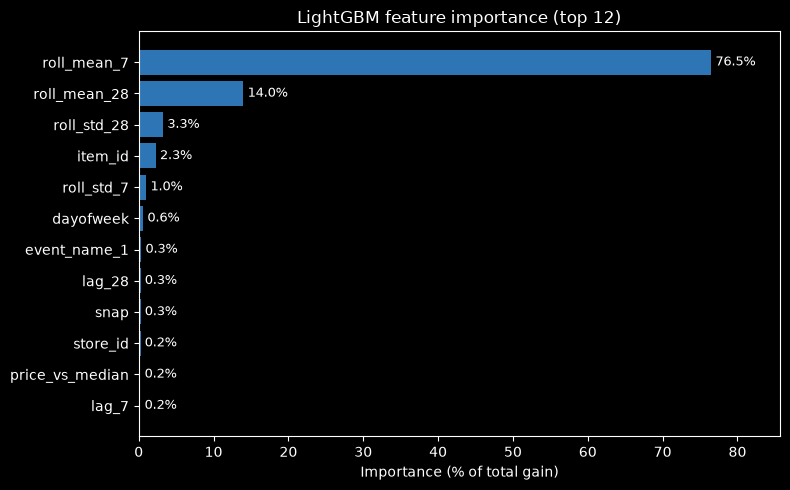

In [27]:
# Feature importance (total gain) from the trained LightGBM model
imp = (pd.DataFrame({
        "feature": model.feature_name(),
        "gain": model.feature_importance(importance_type="gain"),
    })
    .sort_values("gain", ascending=False)
    .reset_index(drop=True))
imp["gain_pct"] = 100 * imp["gain"] / imp["gain"].sum()

# horizontal bar chart of top 12, with % labels on the bars
top = imp.head(12).iloc[::-1]   # reverse so largest is on top
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top["feature"], top["gain_pct"], color="#2E75B6")
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in top["gain_pct"]],
             padding=3, fontsize=9)
ax.set_xlabel("Importance (% of total gain)")
ax.set_title("LightGBM feature importance (top 12)")
ax.set_xlim(0, top["gain_pct"].max() * 1.12)
plt.tight_layout(); plt.show()

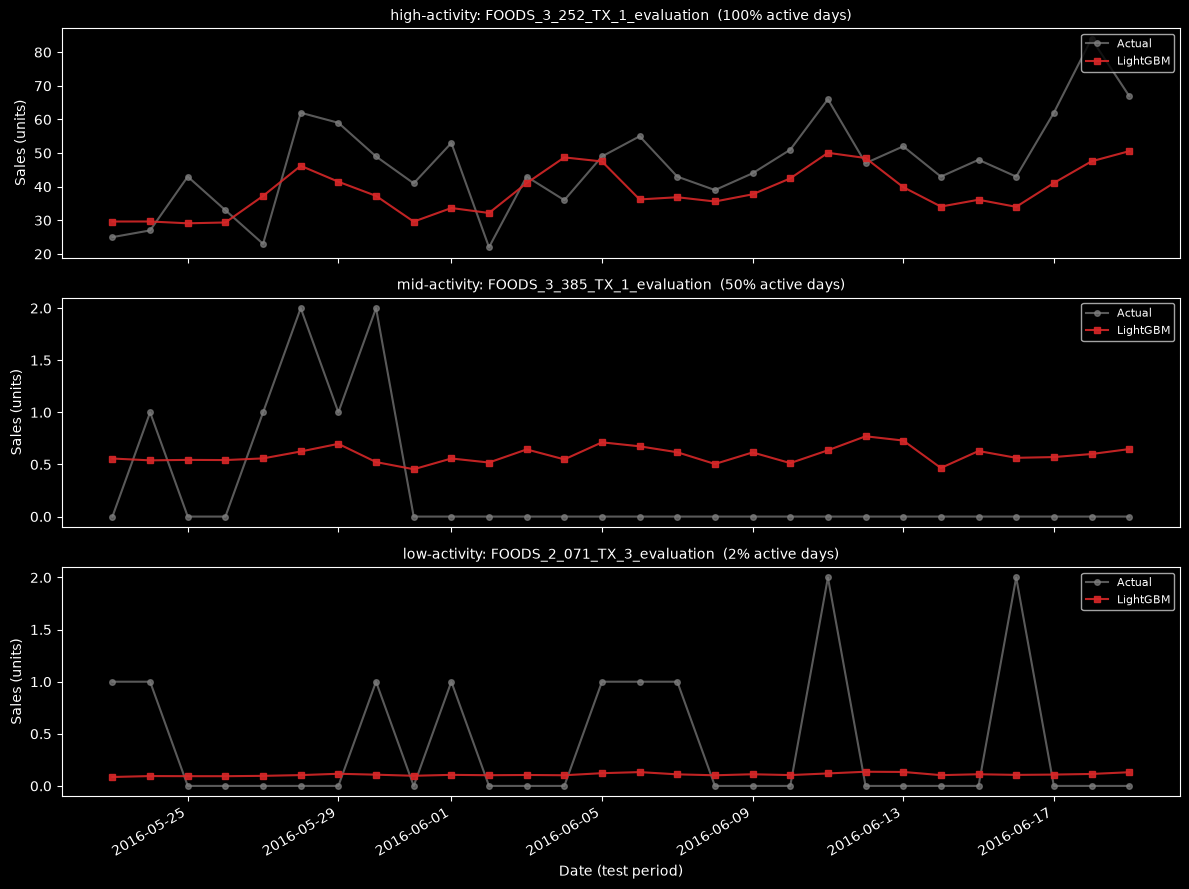

In [33]:
# LightGBM forecast vs actual for 3 representative series (high / mid / low activity)
import matplotlib.dates as mdates
import pandas as pd

# d_num -> real calendar date (M5: d_1 = 2011-01-29), works for any d_num incl. test period
M5_START = pd.Timestamp("2011-01-29")
def dnum_to_date(dn):
    return M5_START + pd.to_timedelta(dn - 1, unit="D")

sub = series_info[series_info["id"].isin(subset_ids)]
demo = {
    "high": sub.loc[sub["active_ratio"].idxmax(), "id"],
    "mid":  sub.iloc[(sub["active_ratio"] - 0.5).abs().argsort().iloc[0]]["id"],
    "low":  sub.loc[sub["active_ratio"].idxmin(), "id"],
}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (tier, sid) in zip(axes, demo.items()):
    actual = test_long[test_long["id"] == sid].sort_values("d_num")
    pred   = lgb_preds[lgb_preds["id"] == sid].sort_values("d_num")
    ax.plot(dnum_to_date(actual["d_num"]), actual["sales"], "o-", ms=4,
            color="gray", label="Actual", alpha=0.7)
    ax.plot(dnum_to_date(pred["d_num"]), pred["prediction"], "s-", ms=4,
            color="#d62728", label="LightGBM", alpha=0.9)
    act = sub.loc[sub["id"] == sid, "active_ratio"].iloc[0]
    ax.set_title(f"{tier}-activity: {sid}  ({act*100:.0f}% active days)", fontsize=10)
    ax.set_ylabel("Sales (units)")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[-1].set_xlabel("Date (test period)")
fig.autofmt_xdate()
plt.tight_layout(); plt.show()

In [37]:
# ============ Feature importance stability across seeds ============
# reuse the same training matrix as the main model (X_train, y_train, categorical_feats)
# retrain with a few different seeds; compare top-feature rankings
seeds = [1, 42, 123, 2024]
imp_by_seed = {}

base_params = dict(
    objective="tweedie", tweedie_variance_power=1.1,
    num_leaves=63, learning_rate=0.05, min_data_in_leaf=100,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
    verbose=-1,
)

for sd in seeds:
    p = dict(base_params, seed=sd, bagging_seed=sd, feature_fraction_seed=sd)
    m = lgb.train(p, train_set, num_boost_round=300,
                  valid_sets=[val_set], callbacks=[lgb.early_stopping(30, verbose=False)])
    imp = pd.Series(m.feature_importance(importance_type="gain"),
                    index=m.feature_name())
    imp_by_seed[sd] = (imp / imp.sum() * 100)   # as % of gain

stab = pd.DataFrame(imp_by_seed)
stab["mean"] = stab.mean(axis=1)
stab["std"]  = stab[seeds].std(axis=1)
stab = stab.sort_values("mean", ascending=False)

print("=== Feature importance (% gain) across seeds — top 8 ===")
print(stab.head(8).round(2).to_string())

# rank stability: does the top-5 set stay the same?
top5_sets = [set(stab[s].sort_values(ascending=False).head(5).index) for s in seeds]
common = set.intersection(*top5_sets)
print(f"\nFeatures in EVERY seed's top-5: {sorted(common)}")
print(f"Top-5 fully stable: {all(t == top5_sets[0] for t in top5_sets)}")

=== Feature importance (% gain) across seeds — top 8 ===
                  1     42    123   2024   mean    std
roll_mean_7   81.87  71.23  56.09  63.89  68.27  10.97
roll_mean_28   8.26  19.10  36.28  28.10  22.94  12.04
roll_std_28    4.30   3.54   1.85   2.06   2.94   1.18
item_id        1.89   1.89   1.93   1.95   1.91   0.03
roll_std_7     0.92   1.52   1.28   1.40   1.28   0.26
dayofweek      0.54   0.60   0.67   0.71   0.63   0.08
event_name_1   0.33   0.33   0.33   0.33   0.33   0.00
snap           0.25   0.25   0.26   0.26   0.25   0.00

Features in EVERY seed's top-5: ['item_id', 'roll_mean_28', 'roll_mean_7', 'roll_std_28', 'roll_std_7']
Top-5 fully stable: True
